In [1]:
print("=" * 60)
print("ONLINE TRANSACTION FRAUD DETECTION")
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

ONLINE TRANSACTION FRAUD DETECTION
EXPLORATORY DATA ANALYSIS (EDA)


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("dataset/synthetic_fraud_dataset.csv")

print("dataset loaded successfully")

dataset loaded successfully


In [4]:
df.head()

,Transaction_ID,Time,Transaction_Date,Hour,Day_Of_Week,Is_Weekend,Is_Night_Transaction,Amount,Transaction_Type,Merchant_Category,Device_Type,City,Country,International_Transaction,Failed_Login_Attempts,Previous_Transactions_24H,Unusual_Location,VPN_Used,Multiple_Cards_Used,New_Device_Login,Account_Age_Days,Transaction_Velocity,Risk_Score,Is_Fraud
0,TXN00104242,16122600,2025-12-03 13:26:30,13,2,0,0,11027.61,Credit Card,Gaming,Android,Pune,India,0,1,9,0,0,0,0,2149,3,23,0
1,TXN00199677,29893920,2026-05-11 22:48:30,22,0,0,0,1676.18,Bank Transfer,Crypto,Laptop,Pune,India,0,1,2,0,0,0,0,1929,3,23,0
2,TXN00140200,14432760,2025-11-14 00:02:30,0,4,0,1,610.47,ATM,Insurance,iPhone,Ahmedabad,India,0,1,11,0,1,0,0,2884,3,23,0
3,TXN00132815,1475760,2025-06-17 00:52:30,0,1,0,1,1262.61,Debit Card,Travel,Laptop,Delhi,India,0,2,12,0,0,0,1,763,1,23,0
4,TXN00408698,27676500,2026-04-16 06:51:30,6,3,0,0,1074.08,UPI,Food,Tablet,Kolkata,India,0,1,1,1,0,0,0,1709,1,22,0


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.shape

Rows: 500000
Columns: 24


(500000, 24)

In [6]:
df.columns.tolist()

['Transaction_ID',
 'Time',
 'Transaction_Date',
 'Hour',
 'Day_Of_Week',
 'Is_Weekend',
 'Is_Night_Transaction',
 'Amount',
 'Transaction_Type',
 'Merchant_Category',
 'Device_Type',
 'City',
 'Country',
 'International_Transaction',
 'Failed_Login_Attempts',
 'Previous_Transactions_24H',
 'Unusual_Location',
 'VPN_Used',
 'Multiple_Cards_Used',
 'New_Device_Login',
 'Account_Age_Days',
 'Transaction_Velocity',
 'Risk_Score',
 'Is_Fraud']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Transaction_ID             500000 non-null  object 
 1   Time                       500000 non-null  int64  
 2   Transaction_Date           500000 non-null  object 
 3   Hour                       500000 non-null  int64  
 4   Day_Of_Week                500000 non-null  int64  
 5   Is_Weekend                 500000 non-null  int64  
 6   Is_Night_Transaction       500000 non-null  int64  
 7   Amount                     500000 non-null  float64
 8   Transaction_Type           500000 non-null  object 
 9   Merchant_Category          500000 non-null  object 
 10  Device_Type                500000 non-null  object 
 11  City                       500000 non-null  object 
 12  Country                    500000 non-null  object 
 13  International_Transaction  50

In [8]:
missing = df.isnull().sum()

missing

Transaction_ID               0
Time                         0
Transaction_Date             0
Hour                         0
Day_Of_Week                  0
Is_Weekend                   0
Is_Night_Transaction         0
Amount                       0
Transaction_Type             0
Merchant_Category            0
Device_Type                  0
City                         0
Country                      0
International_Transaction    0
Failed_Login_Attempts        0
Previous_Transactions_24H    0
Unusual_Location             0
VPN_Used                     0
Multiple_Cards_Used          0
New_Device_Login             0
Account_Age_Days             0
Transaction_Velocity         0
Risk_Score                   0
Is_Fraud                     0
dtype: int64

In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Records: ",duplicates)

Duplicate Records:  0


In [10]:
df.describe()

,Time,Hour,Day_Of_Week,Is_Weekend,Is_Night_Transaction,Amount,International_Transaction,Failed_Login_Attempts,Previous_Transactions_24H,Unusual_Location,VPN_Used,Multiple_Cards_Used,New_Device_Login,Account_Age_Days,Transaction_Velocity,Risk_Score,Is_Fraud
count,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,1.576913e+07,11.500428,3.011096,0.288704,0.291404,7598.481319,0.021760,0.543280,6.640586,0.173910,0.136868,0.115896,0.171650,1491.954696,3.282606,23.503792,0.040000
std,9.108328e+06,6.920403,2.000650,0.453160,0.454410,21132.888738,0.145899,1.011405,3.658644,0.379032,0.343708,0.320100,0.377076,862.380177,2.944211,18.301817,0.195959
min,6.000000e+01,0.000000,0.000000,0.000000,0.000000,46.360000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000
25%,7.879005e+06,6.000000,1.000000,0.000000,0.000000,1325.077500,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,733.000000,2.000000,13.000000,0.000000
50%,1.577328e+07,11.000000,3.000000,0.000000,0.000000,2355.270000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,1482.000000,3.000000,20.000000,0.000000
75%,2.365770e+07,18.000000,5.000000,1.000000,1.000000,4340.812500,0.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,2241.000000,4.000000,29.000000,0.000000
max,3.153600e+07,23.000000,6.000000,1.000000,1.000000,199905.200000,1.000000,8.000000,20.000000,1.000000,1.000000,1.000000,1.000000,3000.000000,30.000000,100.000000,1.000000


In [11]:
df["Is_Fraud"].value_counts()

Is_Fraud
0    480000
1     20000
Name: count, dtype: int64

In [12]:
df["Is_Fraud"].value_counts(normalize=True) * 100

Is_Fraud
0    96.0
1     4.0
Name: proportion, dtype: float64

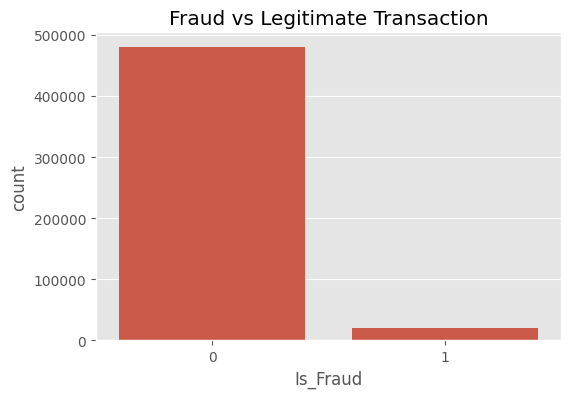

In [13]:
# fraud distribution grapg

plt.figure(figsize=(6,4))

sns.countplot(
    x="Is_Fraud",
    data=df
)

plt.title("Fraud vs Legitimate Transaction")
plt.show()

Text(0.5, 1.0, 'Fraud Distribution')

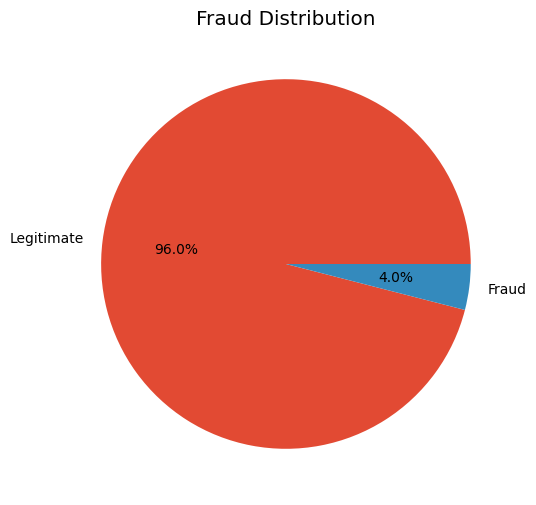

In [14]:
# fraud percentage pir chart

fraud_counts = df["Is_Fraud"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud_counts,
    labels=["Legitimate", "Fraud"],
    autopct="%1.1f%%"
)

plt.title("Fraud Distribution")

Text(0.5, 1.0, 'Transaction Amount Distribution')

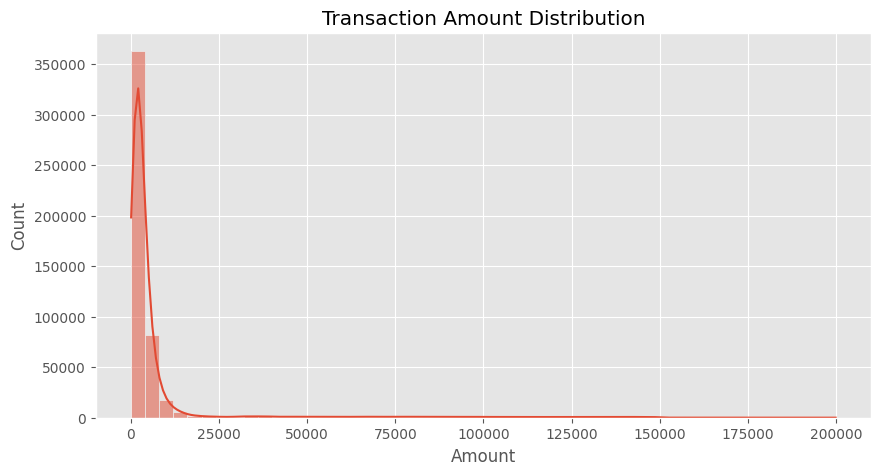

In [15]:
# amount distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")

Text(0.5, 1.0, 'Amount Outlier detection')

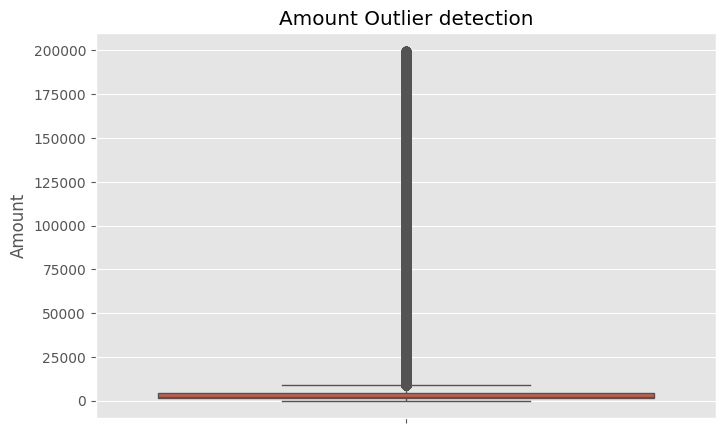

In [16]:
# amount boxplot

plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Amount"]
)

plt.title("Amount Outlier detection")

Text(0.5, 1.0, 'Fraud vs Amount')

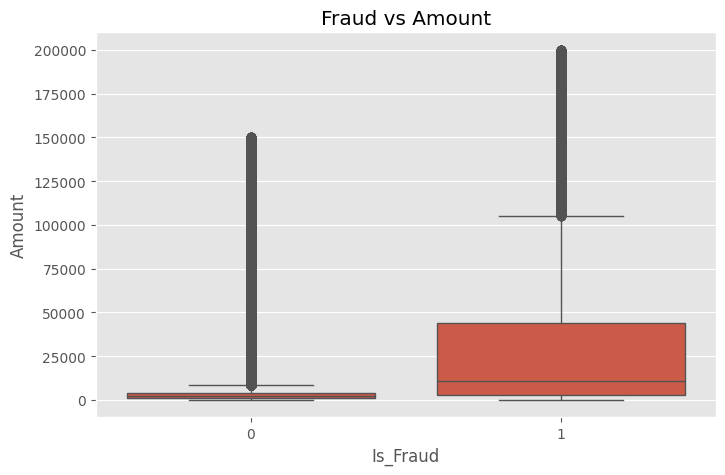

In [17]:
# fraud vs amount

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Is_Fraud",
    y="Amount",
    data=df
)

plt.title("Fraud vs Amount")

Text(0.5, 1.0, 'Fraud vs Risk Score')

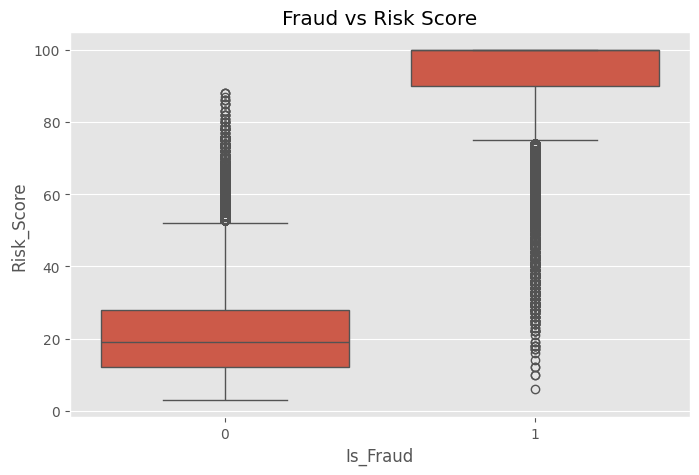

In [18]:
# risk score analysis

plt.figure(figsize=(8,5))

sns.boxplot(
    x = "Is_Fraud",
    y="Risk_Score",
    data=df
)

plt.title("Fraud vs Risk Score")

Text(0.5, 1.0, 'Fraud vs Transaction Velocity')

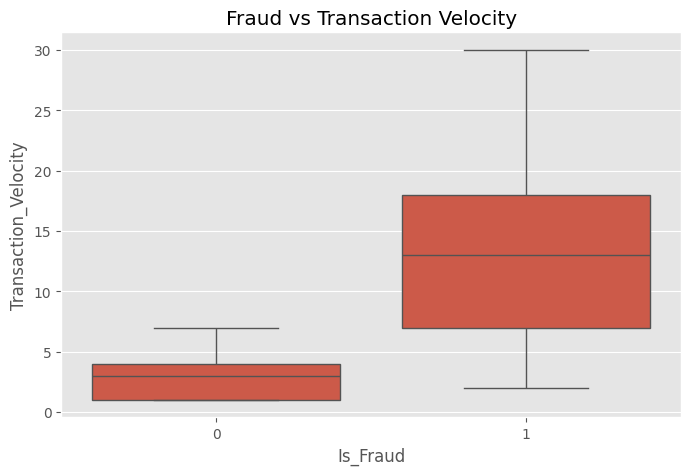

In [19]:
# ttransaction velocity analysis

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Is_Fraud",
    y="Transaction_Velocity",
    data=df
)

plt.title("Fraud vs Transaction Velocity")

Text(0.5, 1.0, 'Fraud vs Transaction Velocity')

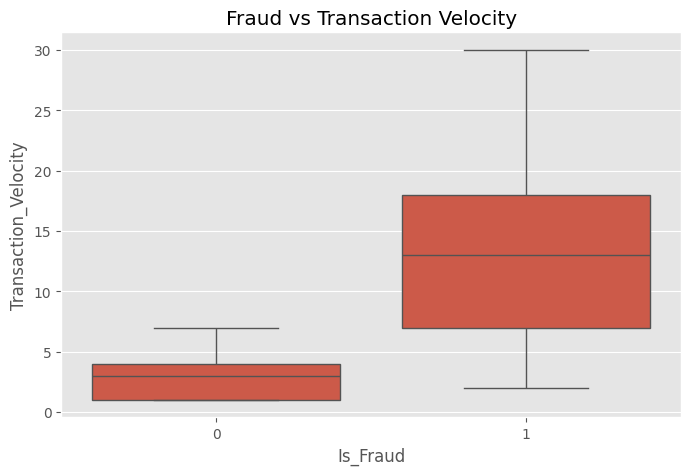

In [20]:
# account age analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Is_Fraud",
    y="Transaction_Velocity",
    data=df
)

plt.title("Fraud vs Transaction Velocity")

Text(0.5, 1.0, 'Fraud vs Failed Login Attempts')

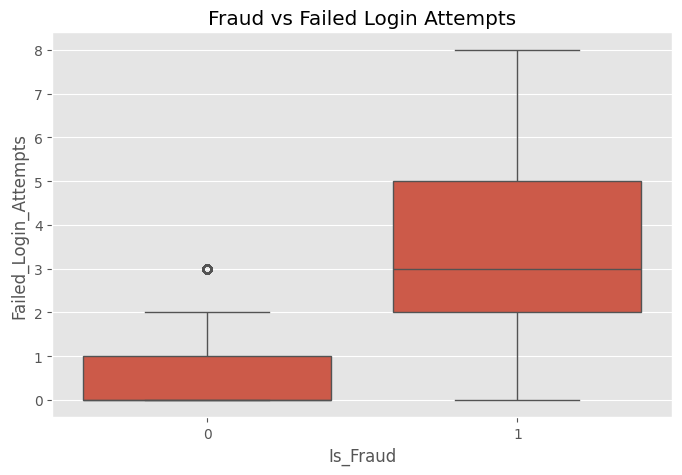

In [21]:
# failed login analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Is_Fraud",
    y="Failed_Login_Attempts",
    data=df
)

plt.title("Fraud vs Failed Login Attempts")

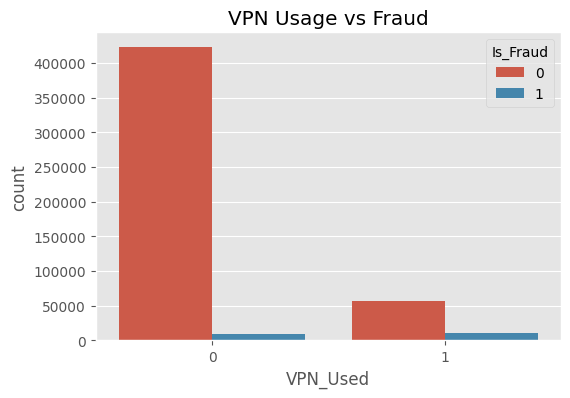

In [22]:
# VPN analysis
plt.figure(figsize=(6,4))

sns.countplot(
    x="VPN_Used",
    hue="Is_Fraud",
    data=df
)

plt.title("VPN Usage vs Fraud")

plt.show()

Text(0.5, 1.0, 'New Device Login vs Fraud')

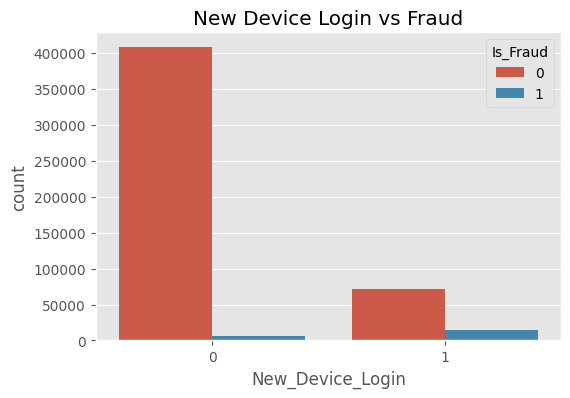

In [23]:
# new device analysis

plt.figure(figsize=(6,4))

sns.countplot(
    x="New_Device_Login",
    hue="Is_Fraud",
    data=df
)

plt.title("New Device Login vs Fraud")

Text(0.5, 1.0, 'International Transaction vs Fraud')

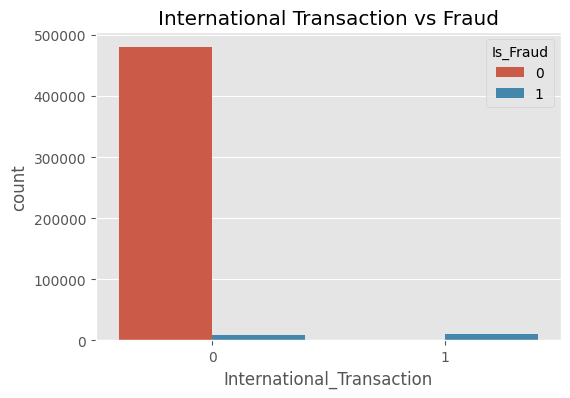

In [24]:
# International Transaction analysis
plt.figure(figsize=(6,4))

sns.countplot(
    x="International_Transaction",
    hue="Is_Fraud",
    data=df
)

plt.title("International Transaction vs Fraud")

Text(0.5, 1.0, 'Unusual Location vs Fraud')

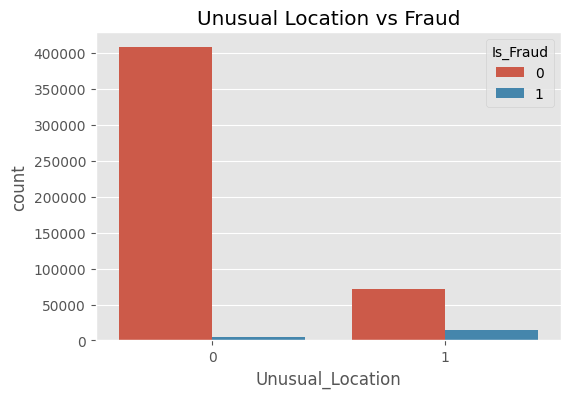

In [25]:
# unusual location analysis
plt.figure(figsize=(6,4))

sns.countplot(
    x="Unusual_Location",
    hue="Is_Fraud",
    data=df
)

plt.title("Unusual Location vs Fraud")

Text(0.5, 1.0, 'Transaction Type vs Fraud')

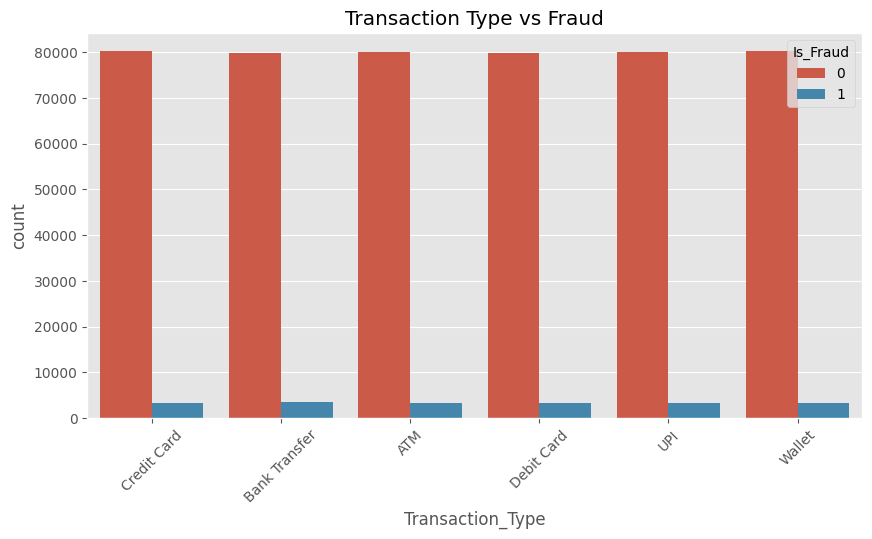

In [26]:
# Transaction type analysis

plt.figure(figsize=(10,5))

sns.countplot(
    x="Transaction_Type",
    hue="Is_Fraud",
    data=df
)

plt.xticks(rotation=45)

plt.title("Transaction Type vs Fraud")

Text(0.5, 1.0, 'Merchant Category vs Fraud')

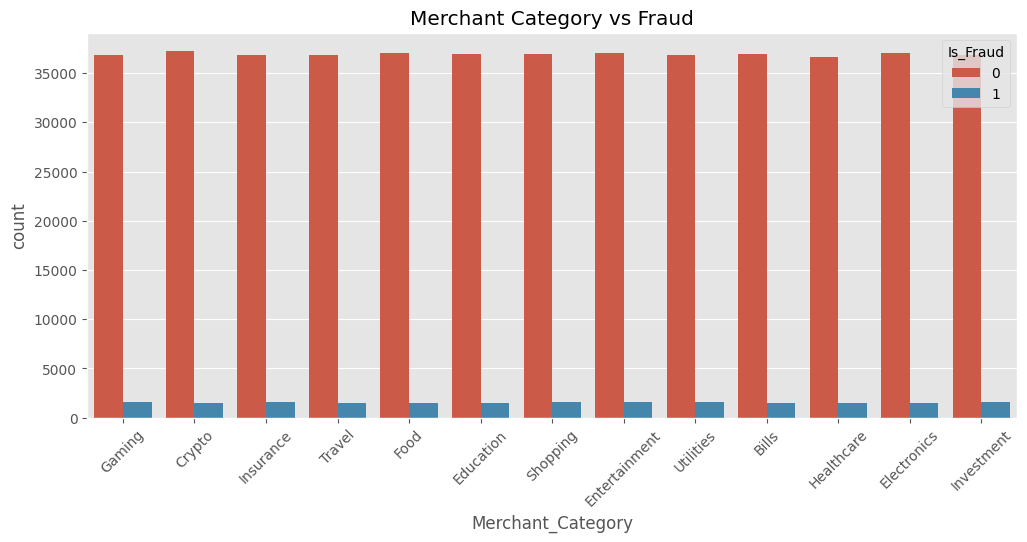

In [27]:
# Merchant category analysis

plt.figure(figsize=(12,5))

sns.countplot(
    x="Merchant_Category",
    hue="Is_Fraud",
    data=df
)

plt.xticks(rotation=45)

plt.title("Merchant Category vs Fraud")

Text(0.5, 1.0, 'Hourly Fraud Pattern')

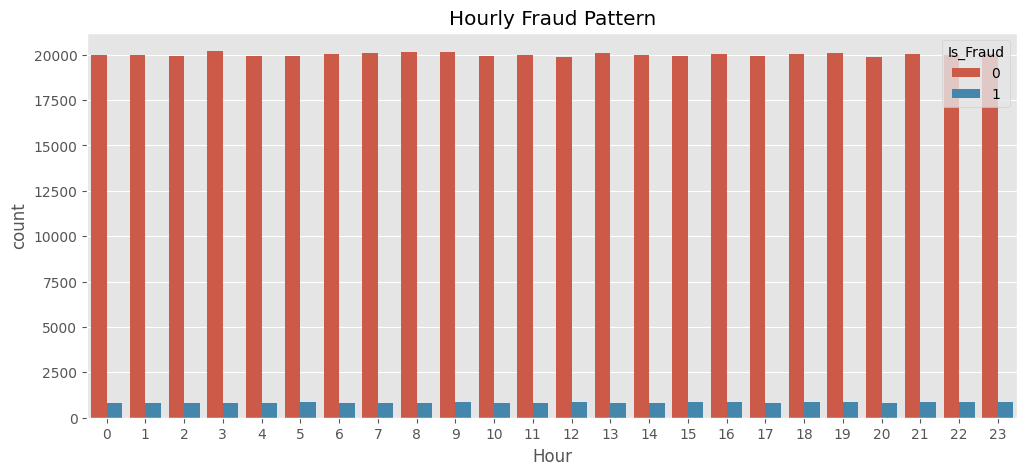

In [28]:
# hourly fraud pattern
plt.figure(figsize=(12,5))

sns.countplot(
    x="Hour",
    hue="Is_Fraud",
    data=df
)

plt.title("Hourly Fraud Pattern")

Text(0.5, 1.0, 'Weekend Fraud Analysis')

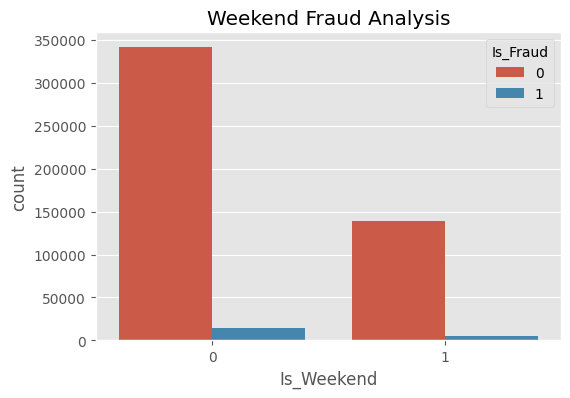

In [29]:
# Weekend analysis

plt.figure(figsize=(6,4))

sns.countplot(
    x="Is_Weekend",
    hue="Is_Fraud",
    data=df
)

plt.title("Weekend Fraud Analysis")

Text(0.5, 1.0, 'Correlation Heatmap')

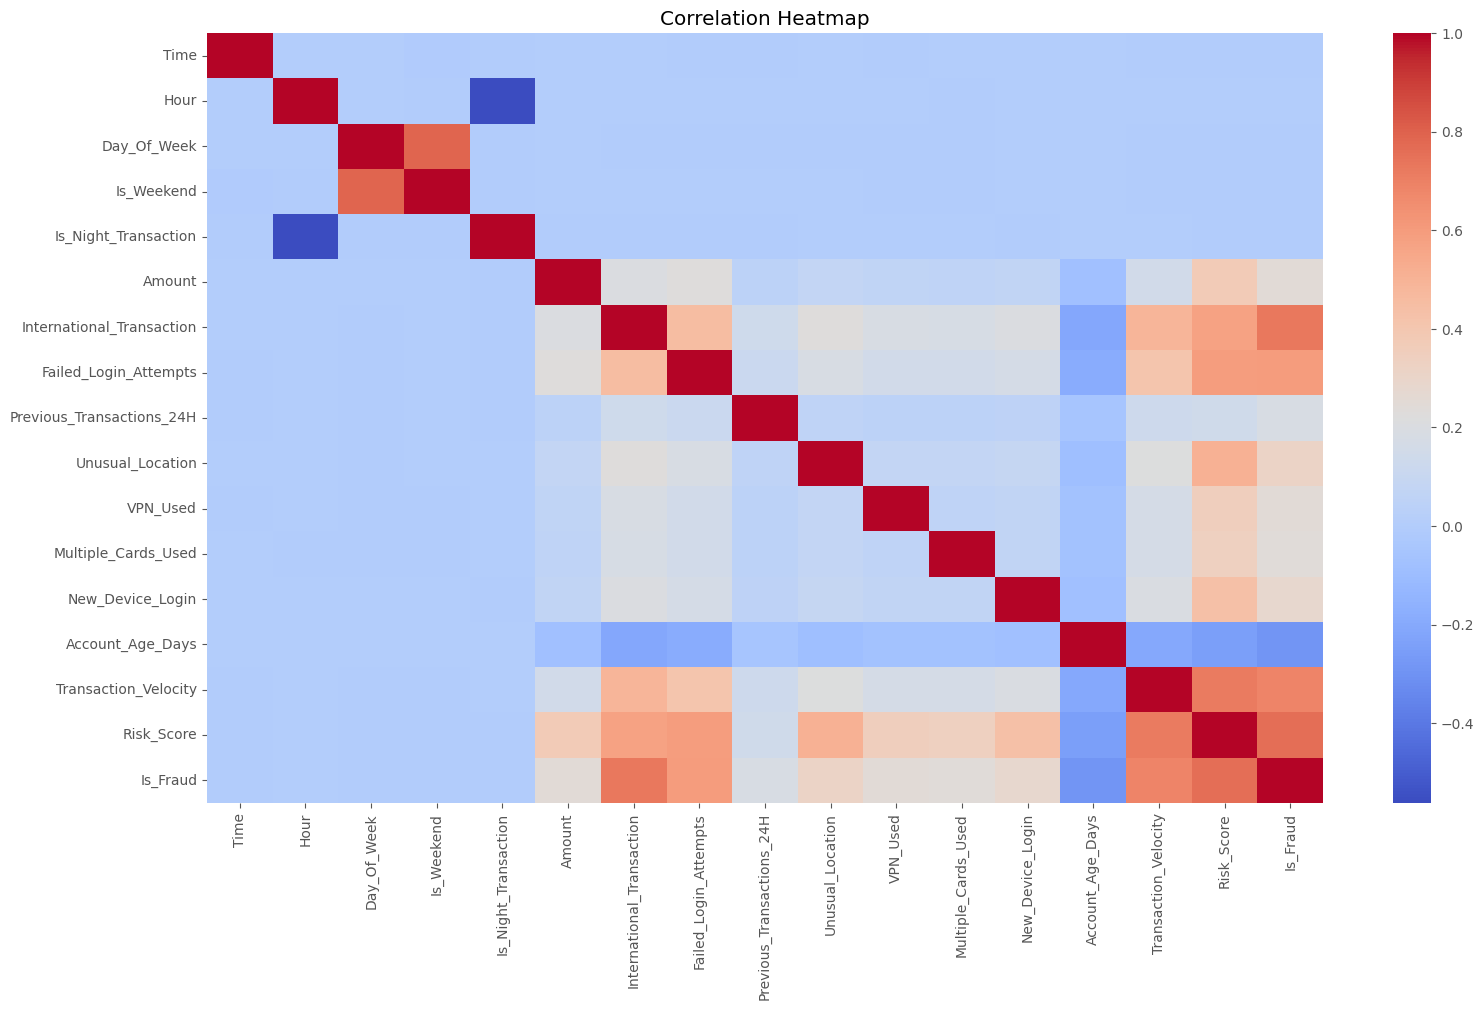

In [30]:
# Correlation Heatmap
plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

In [31]:
# Top correlations with fraud
corr = df.corr(numeric_only=True)

corr["Is_Fraud"].sort_values(
    ascending=False
) 

Is_Fraud                     1.000000
Risk_Score                   0.757024
International_Transaction    0.730655
Transaction_Velocity         0.685025
Failed_Login_Attempts        0.601011
Unusual_Location             0.311002
New_Device_Login             0.284065
Amount                       0.247943
VPN_Used                     0.246987
Multiple_Cards_Used          0.243185
Previous_Transactions_24H    0.188545
Hour                         0.002579
Time                        -0.000672
Is_Night_Transaction        -0.000721
Is_Weekend                  -0.000768
Day_Of_Week                 -0.003382
Account_Age_Days            -0.291653
Name: Is_Fraud, dtype: float64

In [32]:
# Mean feature comparison
df.groupby(
    "Is_Fraud"
).mean(
    numeric_only=True
)

,Time,Hour,Day_Of_Week,Is_Weekend,Is_Night_Transaction,Amount,International_Transaction,Failed_Login_Attempts,Previous_Transactions_24H,Unusual_Location,VPN_Used,Multiple_Cards_Used,New_Device_Login,Account_Age_Days,Transaction_Velocity,Risk_Score
Is_Fraud,,,,,,,,,,,,,,,,
0,1.577038e+07,11.496785,3.012477,0.288775,0.291471,6528.924487,0.000,0.4192,6.499777,0.149848,0.11954,0.100006,0.149785,1543.295135,2.870917,20.675673
1,1.573913e+07,11.587850,2.977950,0.287000,0.289800,33267.845286,0.544,3.5212,10.020000,0.751400,0.55275,0.497250,0.696400,259.784150,13.163150,91.378650
